<a href="https://colab.research.google.com/github/Zunera-tech/CodeAlpha_-Disease_Prediction_from_Medical_Data-/blob/main/CodeAlpha_Disease_Prediction_from_Medical_Data_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Disease Prediction — Heart Disease
Predicting the presence of heart disease from patient clinical data.

**Dataset:** Heart Failure Prediction (UCI-derived, 918 patients, 11 features)

**Algorithms:** Logistic Regression, SVM, Random Forest, XGBoost


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("Libraries loaded.")

Libraries loaded.


In [3]:
url = "https://raw.githubusercontent.com/akarshsnair/Dataset-cart/main/heart.csv"
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['HeartDisease'].value_counts())
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head()

Shape: (918, 12)

Target distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64

Missing values:
Cholesterol       1
ExerciseAngina    1
dtype: int64


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


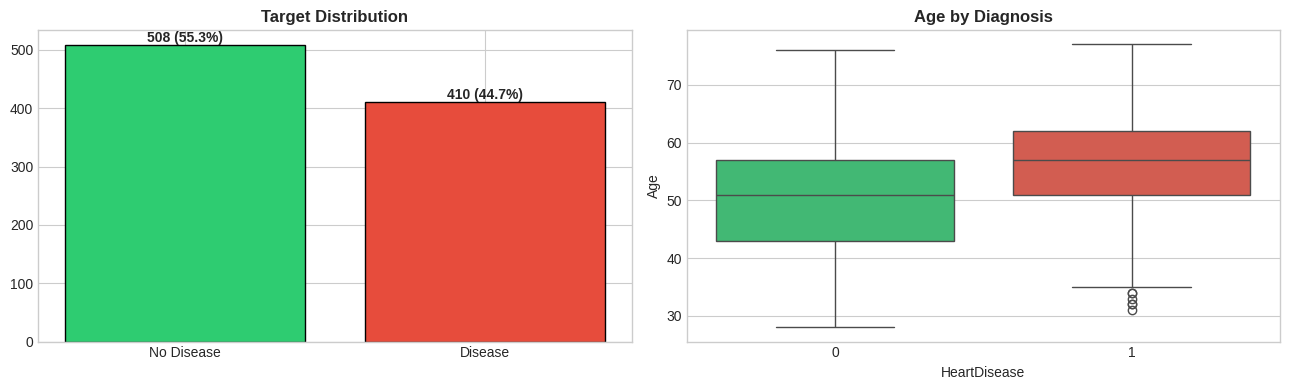

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['HeartDisease'].value_counts()
axes[0].bar(['No Disease', 'Disease'], counts.values, color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[0].set_title('Target Distribution', fontweight='bold')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

sns.boxplot(data=df, x='HeartDisease', y='Age', ax=axes[1], palette=['#2ecc71','#e74c3c'])
axes[1].set_title('Age by Diagnosis', fontweight='bold')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

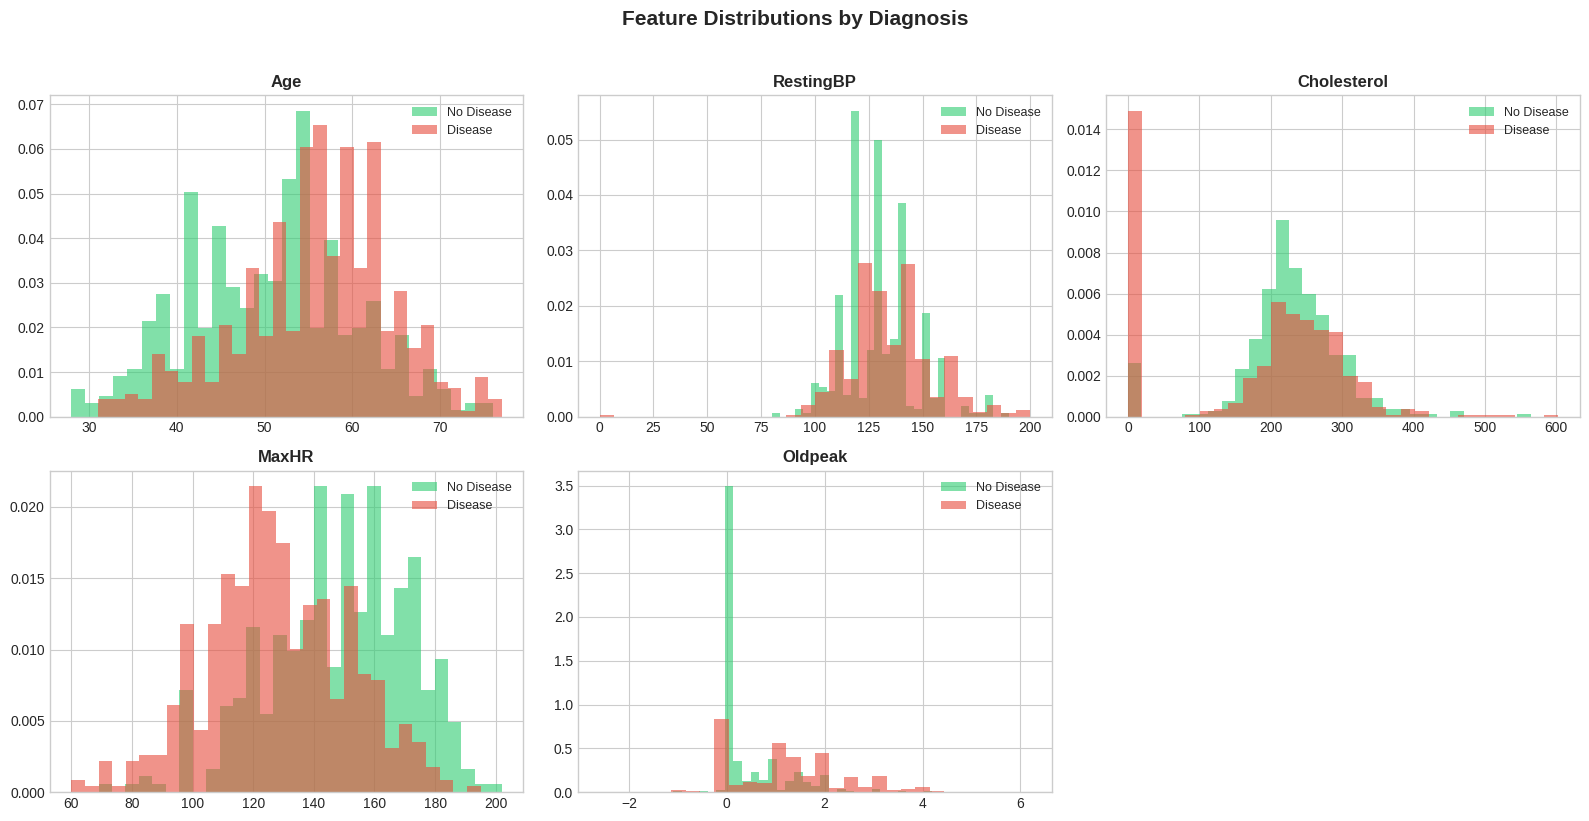

In [5]:
num_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, feat in zip(axes.flatten(), num_features):
    for label, color, name in [(0,'#2ecc71','No Disease'), (1,'#e74c3c','Disease')]:
        ax.hist(df[df['HeartDisease']==label][feat], bins=30, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=9)

axes[-1,-1].axis('off')
plt.suptitle('Feature Distributions by Diagnosis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

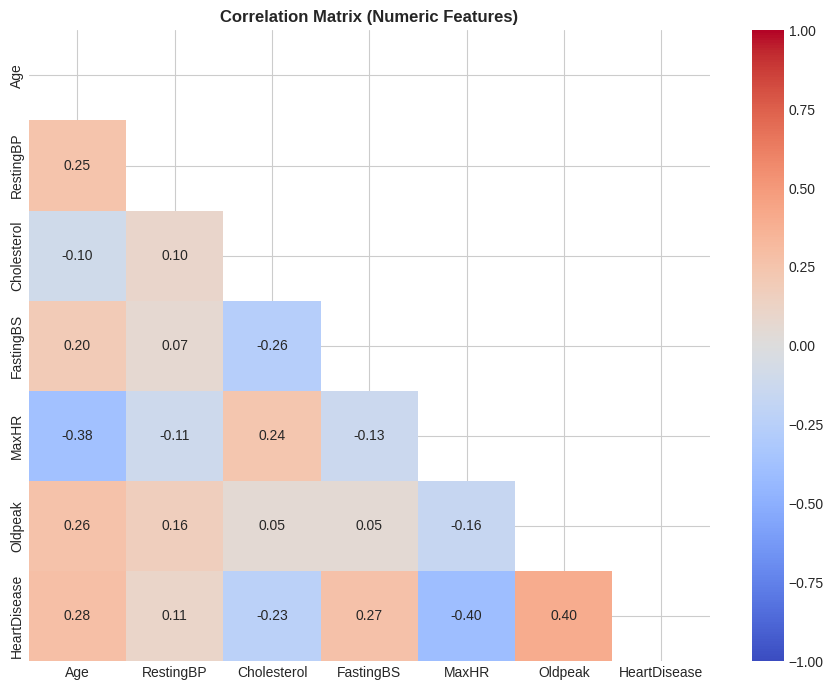

In [6]:
plt.figure(figsize=(9, 7))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, vmin=-1, vmax=1)
plt.title('Correlation Matrix (Numeric Features)', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
df_clean = df.copy()

# Some records have Cholesterol=0, which is physiologically impossible —
# it means "not recorded". Impute with the median of valid (>0) values.
chol_median = df_clean.loc[df_clean['Cholesterol'] > 0, 'Cholesterol'].median()
df_clean['Cholesterol'] = df_clean['Cholesterol'].replace(0, chol_median)

# Same check for RestingBP (a handful of 0s exist)
bp_median = df_clean.loc[df_clean['RestingBP'] > 0, 'RestingBP'].median()
df_clean['RestingBP'] = df_clean['RestingBP'].replace(0, bp_median)

# Encode categorical columns
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

TARGET = 'HeartDisease'
FEATURE_COLS = [c for c in df_encoded.columns if c != TARGET]
X = df_encoded[FEATURE_COLS]
y = df_encoded[TARGET]

print(f"Features after encoding: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

# Check for any remaining missing values (blank cells in the source CSV)
print("Missing values before final cleanup:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Numeric columns: impute with median
num_cols = df_clean.select_dtypes(include=np.number).columns.drop('HeartDisease')
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical columns: impute with mode (most frequent value)
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("\nMissing values after cleanup:", df_clean.isnull().sum().sum())

Features after encoding: 16
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up', 'ST_Slope_t']
Missing values before final cleanup:
Cholesterol       1
ExerciseAngina    1
dtype: int64

Missing values after cleanup: 0


In [15]:
df_clean = df.copy()

# Some records have Cholesterol=0, which is physiologically impossible —
# it means "not recorded". Impute with the median of valid (>0) values.
chol_median = df_clean.loc[df_clean['Cholesterol'] > 0, 'Cholesterol'].median()
df_clean['Cholesterol'] = df_clean['Cholesterol'].replace(0, chol_median)

# Same check for RestingBP (a handful of 0s exist)
bp_median = df_clean.loc[df_clean['RestingBP'] > 0, 'RestingBP'].median()
df_clean['RestingBP'] = df_clean['RestingBP'].replace(0, bp_median)

cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# Check for any remaining missing values (blank cells in the source CSV)
print("Missing values before final cleanup:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Numeric columns: impute with median
num_cols = df_clean.select_dtypes(include=np.number).columns.drop('HeartDisease')
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical columns: impute with mode (most frequent value)
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("\nMissing values after cleanup:", df_clean.isnull().sum().sum())

# Encode categorical columns
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

TARGET = 'HeartDisease'
FEATURE_COLS = [c for c in df_encoded.columns if c != TARGET]
X = df_encoded[FEATURE_COLS]
y = df_encoded[TARGET]

print(f"\nFeatures after encoding: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

Missing values before final cleanup:
Cholesterol       1
ExerciseAngina    1
dtype: int64

Missing values after cleanup: 0

Features after encoding: 16
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up', 'ST_Slope_t']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")

Train: 734 | Test: 184
Train class balance:
HeartDisease
1    0.553
0    0.447
Name: proportion, dtype: float64


In [19]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'SVM': SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                              use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}
for name, model in models.items():
    print(f"Training {name}...", end=' ')
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }
    print(f"ROC-AUC={results[name]['ROC-AUC']:.4f}")

Training Logistic Regression... ROC-AUC=0.9324
Training SVM... ROC-AUC=0.9433
Training Random Forest... ROC-AUC=0.9265
Training XGBoost... ROC-AUC=0.9198


In [20]:
metrics_df = pd.DataFrame({
    name: {k: f"{v:.4f}" for k, v in res.items() if k not in ['model','y_pred','y_prob']}
    for name, res in results.items()
}).T
print(metrics_df.to_string())

best_model_name = max(results, key=lambda x: results[x]['ROC-AUC'])
print(f"\nBest Model: {best_model_name} (ROC-AUC = {results[best_model_name]['ROC-AUC']:.4f})")

                    Accuracy Precision  Recall F1-Score ROC-AUC
Logistic Regression   0.8913    0.8942  0.9118   0.9029  0.9324
SVM                   0.8587    0.8585  0.8922   0.8750  0.9433
Random Forest         0.8641    0.8889  0.8627   0.8756  0.9265
XGBoost               0.8696    0.8750  0.8922   0.8835  0.9198

Best Model: SVM (ROC-AUC = 0.9433)


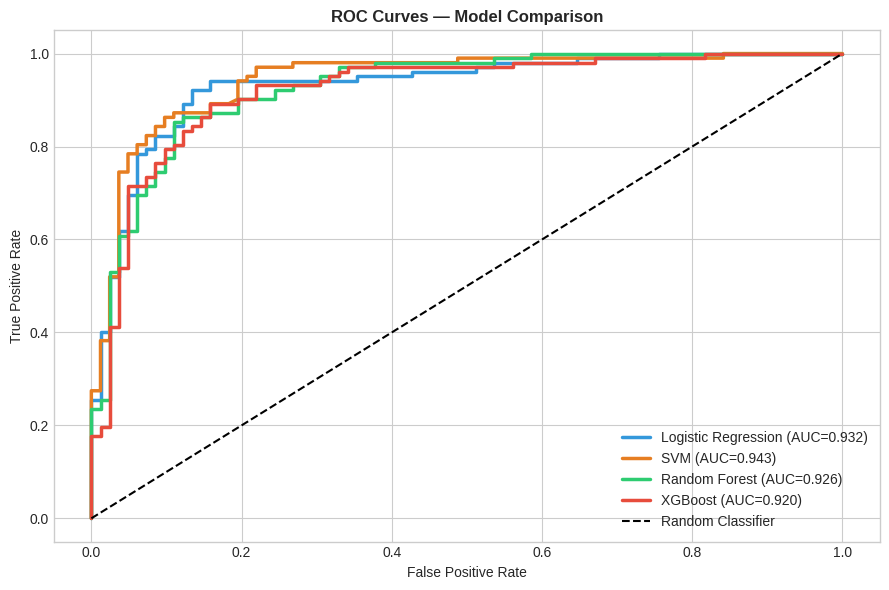

In [21]:
plt.figure(figsize=(9, 6))
colors = ['#3498db','#e67e22','#2ecc71','#e74c3c']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, linewidth=2.5, color=color, label=f"{name} (AUC={res['ROC-AUC']:.3f})")
plt.plot([0,1],[0,1],'k--', label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

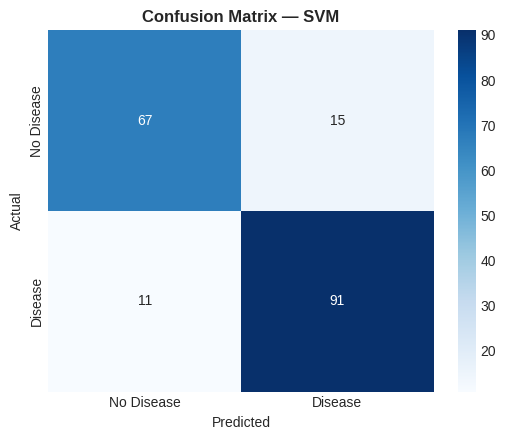

              precision    recall  f1-score   support

  No Disease       0.86      0.82      0.84        82
     Disease       0.86      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.86       184
weighted avg       0.86      0.86      0.86       184



In [22]:
best_res = results[best_model_name]
cm = confusion_matrix(y_test, best_res['y_pred'])

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Disease'], yticklabels=['No Disease','Disease'])
plt.title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test, best_res['y_pred'], target_names=['No Disease','Disease']))

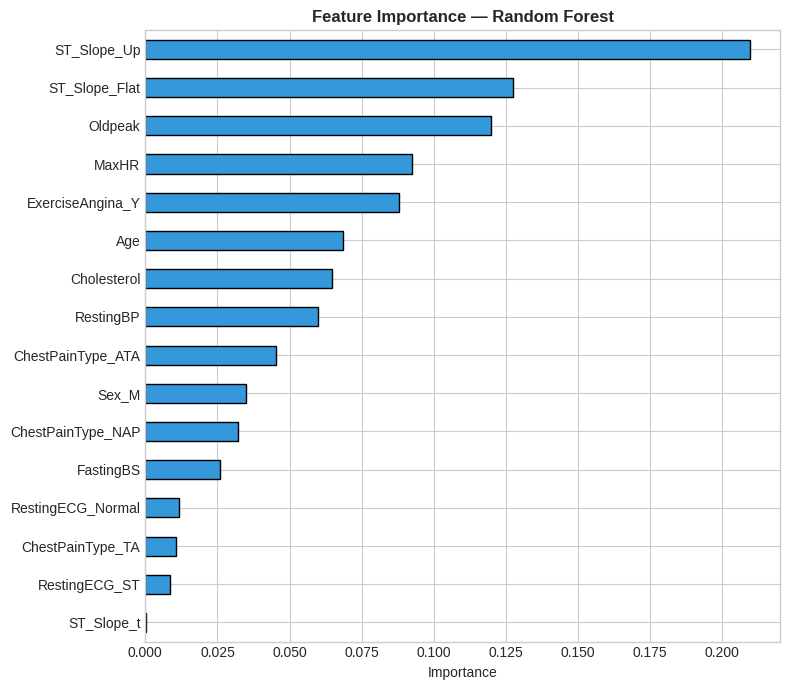

In [24]:
importances = pd.Series(results['Random Forest']['model'].feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 7))
importances.plot(kind='barh', color='#3498db', edgecolor='black')
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()